# Proyecto ICA
### Simulación de datos a partir de muestras

#### Carga de datos.
Realizamos carga de datos desde el archivo excel recibido del dpto de ing. quimica.
Asimismo se da comienzo al código del proyecto importando bibliotecas necesarias

In [32]:
!pip install numpy scipy pandas matplotlib seaborn

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

# Ruta al archivo de Excel
archivo_excel = '~/Escritorio/ProyectoICA/IIYNT-REQ-BD-001.xlsx' 
#archivo_excel = './IIYNT-REQ-BD-001.xlsx' 

# archivo_excel = '../../../Escritorio/ProyectoICA/IIYNT-REQ-BD-001.xlsx' 

# Número de la fila desde la cual querés empezar (0-indexado)
fila_inicio = 3

# Leer el archivo Excel
init_df = pd.read_excel(archivo_excel)

# Mostrar las primeras filas del DataFrame para confirmar que se leyó bien
init_df.head()



,Buscador por código de muestra,Rótulo de la muestra,Fecha (DD/MM/AAAA),Horario (24 hrs XX:XX),Ubicación,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),...,Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Clasificación según dureza,Cloruros\n(mg Cl-/L),DQO,DBO5,Arsénico total,Unnamed: 21,Unnamed: 22
0,260623ASA,A,2023-06-26 00:00:00,15:00:00,Arroyo Salguero,18.2,0.77,15.2,8.3,990,...,NaN,2.68,212,SEMIDURA,64,NaN,NaN,#REF!,NaN,NaN
1,Código de la muestra\n(fecha-ubicación-número),Rótulo de la muestra,Fecha (DD/MM/AAAA),Horario (24 hrs XX:XX),Ubicación,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),...,Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Clasificación según dureza,Cloruros\n(mg Cl-/L),DQO,DBO5,Arsénico total,NaN,NaN
2,030523ATA,A,2023-05-03 00:00:00,12:30:00,Arroyo_Las Torres,16,0.929,18.5,8.2,1240,...,NaN,NaN,NaN,NaN,NaN,125,NaN,NaN,NaN,NaN
3,090523PBA,A,2023-05-09 00:00:00,14:15:00,Puente Bilbao,17,0.47,19,8.3,1630,...,NaN,NaN,147,BLANDA,156,NaN,NaN,NaN,NaN,Características del muestreo
4,140623PBA,A,2023-06-14 00:00:00,14:30:00,Puente Bilbao,11.9,0.47,13,8.1,1000,...,NaN,41.2,94,BLANDA,78,NaN,NaN,NaN,NaN,Datos meteorológicos (Servicio Meteorológico N...


#### Transformación de Datos
Se seleccionan colúmnas válidas para la simulación

In [3]:

desired_columns = [
    'Temperatura Ambiental (°C)', 
    'Humedad',
    'Temperatura de la muestra (°C)', 
    'pH', 
    'CE\n(µS/cm)', 
    'STD\n(mg/L)',
    'STS\n(mL sed/L)', 
    'OD\n(mg/L)', 
    'Nivel (cm)', 
    'Turbidez (NTU)',
    'Dureza\n(mg CaCO3/L)',
    'Cloruros\n(mg Cl-/L)'
]
df = init_df.iloc[2:102][desired_columns]
df.to_csv("dataset_limpio_para_chatGPT.csv")

Se realiza un control de consistencia de datos verificando que muestras tienen valores nulos

In [4]:
#df.isnull().sum()
df.isna().sum()

Temperatura Ambiental (°C)         0
Humedad                            0
Temperatura de la muestra (°C)     0
pH                                 0
CE\n(µS/cm)                        0
STD\n(mg/L)                        0
STS\n(mL sed/L)                    3
OD\n(mg/L)                         0
Nivel (cm)                        40
Turbidez (NTU)                     2
Dureza\n(mg CaCO3/L)               1
Cloruros\n(mg Cl-/L)               3
dtype: int64

In [7]:
#Eliminar las filas que tienen valores nulos o no asignados
#df.dropna(inplace=True) #aca se modifica el Dataframe original con inplace=true

#Si asigno a nueva variable no hace falta inplace=true pero no modifica el Dataframe original
#df_sin_nulos=df.dropna()

#Como opcion puedo llenar los valores nulos con datos adecuados: 
#fillna(method='bfill') (llenar con el valor siguiente de la columna)
#fillna(method='ffill') (llenar con el valor anterior de la columna)
#fillna(0) (llenar con ceros) 

""" mediaNivel=df['Nivel (cm)'].mean()
df['Nivel (cm)']=df['Nivel (cm)'].fillna(mediaNivel)

mediaSTS=df['STS\n(mL sed/L)'].mean()
df['STS\n(mL sed/L)']=df['STS\n(mL sed/L)'].fillna(mediaSTS)

mediaTurbidez=df['Turbidez (NTU)'].mean()
df['Turbidez (NTU)']=df['Turbidez (NTU)'].fillna(mediaTurbidez)

mediaDureza=df['Dureza\n(mg CaCO3/L)'].mean()
df['Dureza\n(mg CaCO3/L)']=df['Dureza\n(mg CaCO3/L)'].fillna(mediaDureza)

mediaCloruros=df['Cloruros\n(mg Cl-/L)'].mean()
df['Cloruros\n(mg Cl-/L)']=df['Cloruros\n(mg Cl-/L)'].fillna(mediaCloruros) """

df_sin_nulos=df.dropna()
df_sin_nulos.isna().sum()
df_sin_nulos

#Para eliminar columnas con valores nulos uso:
#df_sin_columnas_con_nulos=df.dropna(axis=1)



,Temperatura Ambiental (°C),Humedad,Temperatura de la muestra (°C),pH,CE\n(µS/cm),STD\n(mg/L),STS\n(mL sed/L),OD\n(mg/L),Nivel (cm),Turbidez (NTU),Dureza\n(mg CaCO3/L),Cloruros\n(mg Cl-/L)
42,18,0.6,17.75,7.9,1210,600,92,1.79,27.5,1000,114,97
43,18,0.6,18.05,7.7,1170,580,92,1.35,27.5,1000,114,95
44,18,0.6,18.15,8.1,1000,490,50,4.97,27.5,238,135,79
45,18,0.6,18.15,8.1,1000,490,50,3.12,27.5,351,139,81
46,18,0.6,18.2,8.2,1310,640,64,1.71,47.5,95.6,135,120
47,18,0.6,18.1,8.1,1320,650,64,0.97,47.5,109,130,116
48,18,0.6,18.4,8,750,370,26,4.65,25,11.6,155,50
49,18,0.6,18.35,8,750,370,26,4.84,25,13.5,159,48
50,18,0.6,18.35,8.1,1350,670,56,1.29,35,93.8,143,118
51,18,0.6,18.4,8.1,1340,660,56,1.45,35,159,147,120


## Sección de simulación.
Se utilizarán varias tecnicas de simulación y se expondrán las ventajas y problemas de cada una a continuación.
Si bien utilizo la simulación de Montecarlo para expandir los datos de manera independiente, ésta da diferentes problemas de inconsistencia (como turbidez negativa) que intento afrontar de difersas maneras
Estas maneras son:
1. **Simulación por defecto**: Se expondrán resultados con inconsistencias arrojadas para visualizar el problema

2. **Truncar en valores maximos y minimos**: Cualquier valor fuera del rango es truncado a su contorno

3. **Truncar en Cero**: Cualquier valor negativo se convierte en cero. Es el enfoque más simple, pero puede introducir sesgo en tus simulaciones.

4. **Distribuciones No Negativas**: Usar una distribución que solo genere valores no negativos, como la distribución log-normal o la exponencial. Pero esto puede complicar la interpretación y el ajuste de los datos.

5. **Re-simulación**: Cada vez que se obtiene un valor negativo, se vuelve a simular hasta obtener un valor positivo. Puede ser computacionalmente intensivo si hay muchas re-simulaciones.

6. **Transformación de Datos**: A veces, una transformación (como tomar el logaritmo) hace que los datos se ajusten mejor a una distribución normal. Luego puedes aplicar la transformación inversa a los datos simulados.


#### (A continuación, se definen funciones de apoyo)

In [17]:


def plot_results(df: pd.DataFrame) -> None:
    """
    Función que grafíca el histograma de cada columna del dataframe
    """
    # Determine the number of columns in the data
    n_cols = len(df.columns)

    # Calculate the number of rows needed for the subplots
    n_rows = int(np.ceil(n_cols / 4))

    # Create a figure and a grid of subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, 5 * n_rows))

    # Flatten the array of axes for easier indexing
    axes_flat = axes.flatten() if n_rows > 1 else axes

    # Remove any excess subplots
    for i in range(n_cols, len(axes_flat)):
        fig.delaxes(axes_flat[i])

    # Create histograms
    for i, col in enumerate(df.columns):
        ax = axes_flat[i]
        sns.histplot(df[col], bins=20, color='skyblue', kde=True, ax=ax)
        ax.set_title(f'{col}', fontsize=14)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)

    # Improve the layout
    plt.tight_layout()
    plt.suptitle('Distribución de Variables del Dataset', fontsize=16, y=1.02)
    plt.show()


#### Simulación 1, Simulación por defecto

In [9]:

# Leé el CSV original para no modificar df_sin_nulos por las dudas
df_original = df_sin_nulos.copy()

# Creá un DataFrame vacío para guardar los resultados
df_simulado = pd.DataFrame()

# Número de simulaciones que querés hacer
num_simulaciones = 100000 #Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:


for columna in df_original.columns:
    # Calculá la media y la desviación estándar de cada columna
    media = df_original[columna].mean()
    std = df_original[columna].std()

    # Generá datos aleatorios siguiendo una distribución normal
    datos_simulados = np.random.normal(media, std, num_simulaciones)

    # Añadí estos datos al DataFrame de resultados
    df_simulado[columna] = datos_simulados
    
df_simulado.to_csv("./dataset_simulado_opcion_1.csv")
plot_results(df_simulado)

NameError: name 'plot_results' is not defined

#### Simulación 2, truncar en valores maximos y minimos


In [10]:

# Leé el CSV original para no modificar df_sin_nulos por las dudas
df_original = df_sin_nulos.copy()

# Creá un DataFrame vacío para guardar los resultados
df_simulado = pd.DataFrame()

# Número de simulaciones que querés hacer
num_simulaciones = 100000 #Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:


for columna in df_original.columns:
    # Calculá la media y la desviación estándar de cada columna
    media = df_original[columna].mean()
    std = df_original[columna].std()

    # Generá datos aleatorios siguiendo una distribución normal
    datos_simulados = np.random.normal(media, std, num_simulaciones)

    # Añadí estos datos al DataFrame de resultados
    df_simulado[columna] = datos_simulados
    


""" for i, valor in enumerate(archivo_excel['Turbidez (NTU)']): #esto si fuera un excell pero ya esta como dataframe
    if valor<val_min_STS:val_max_turbidez
       archivo_excel.at[i,'Turbidez (NTU)']=val_min_STS
    if valor>val_max_STS:
       archivo_excel.at[i,'Turbidez (NTU)']=val_max_STS """


#aplico correcciones a la columna STS con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_STS=0.1
val_max_STS=650
df_simulado['STS\n(mL sed/L)'] = df_simulado['STS\n(mL sed/L)'].apply(
    lambda x: val_min_STS if x < val_min_STS else (val_max_STS if x > val_max_STS else x)
)

#aplico correcciones a la columna OD con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_OD=0.0
val_max_OD=9.1
df_simulado['OD\n(mg/L)']=df_simulado['OD\n(mg/L)'].apply(
    lambda x: val_min_OD if x < val_min_OD else (val_max_OD if x > val_max_OD else x)
)

#aplico correcciones a la columna turbidez con el metodo apply que aplica una funcion lambda a cada valor de la columna:
val_min_turbidez=2.7
val_max_turbidez=1000.0
df_simulado['Turbidez (NTU)']=df_simulado['Turbidez (NTU)'].apply(
    lambda x: val_min_turbidez if x < val_min_turbidez else (val_max_turbidez if x > val_max_turbidez else x)
)


#Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:

#Para STD: Es casi exacto no planteo escenarios
# df_simulado['STD\n(mg/L)'] = -0.4958 + 0.4934 * df_simulado['CE\n(µS/cm)']

# #Para Cloruros:
# #Regresion lineal simple
# df_simulado['Cloruros\n(mg Cl-/L)'] = -52.32 + 0.1265 * df_simulado['CE\n(µS/cm)']
# #Escenarios:
# def escenarioCl(valor):
#     probabilidad=np.random.uniform(0,1)
#     if probabilidad <= 0.3:
#         return valor * 0.93
#     elif probabilidad >=0.7:
#         return valor * 1.07
#     else:
#         return valor

# df_simulado['Cloruros\n(mg Cl-/L)'] = df_simulado['Cloruros\n(mg Cl-/L)'].apply(escenarioCl)

# val_min_cloruros=15.0
# val_max_cloruros=156.0
# df_simulado['Cloruros\n(mg Cl-/L)']=df_simulado['Cloruros\n(mg Cl-/L)'].apply(lambda x: val_min_cloruros if x < val_min_cloruros else (val_max_cloruros if x > val_max_cloruros else x))


# Guardá el DataFrame simulado como CSV
df_simulado.to_csv("./dataset_simulado_opcion_2.csv", index=False) #../
plot_results(df_simulado)


NameError: name 'plot_results' is not defined

#### Simulación 3, truncar en Cero

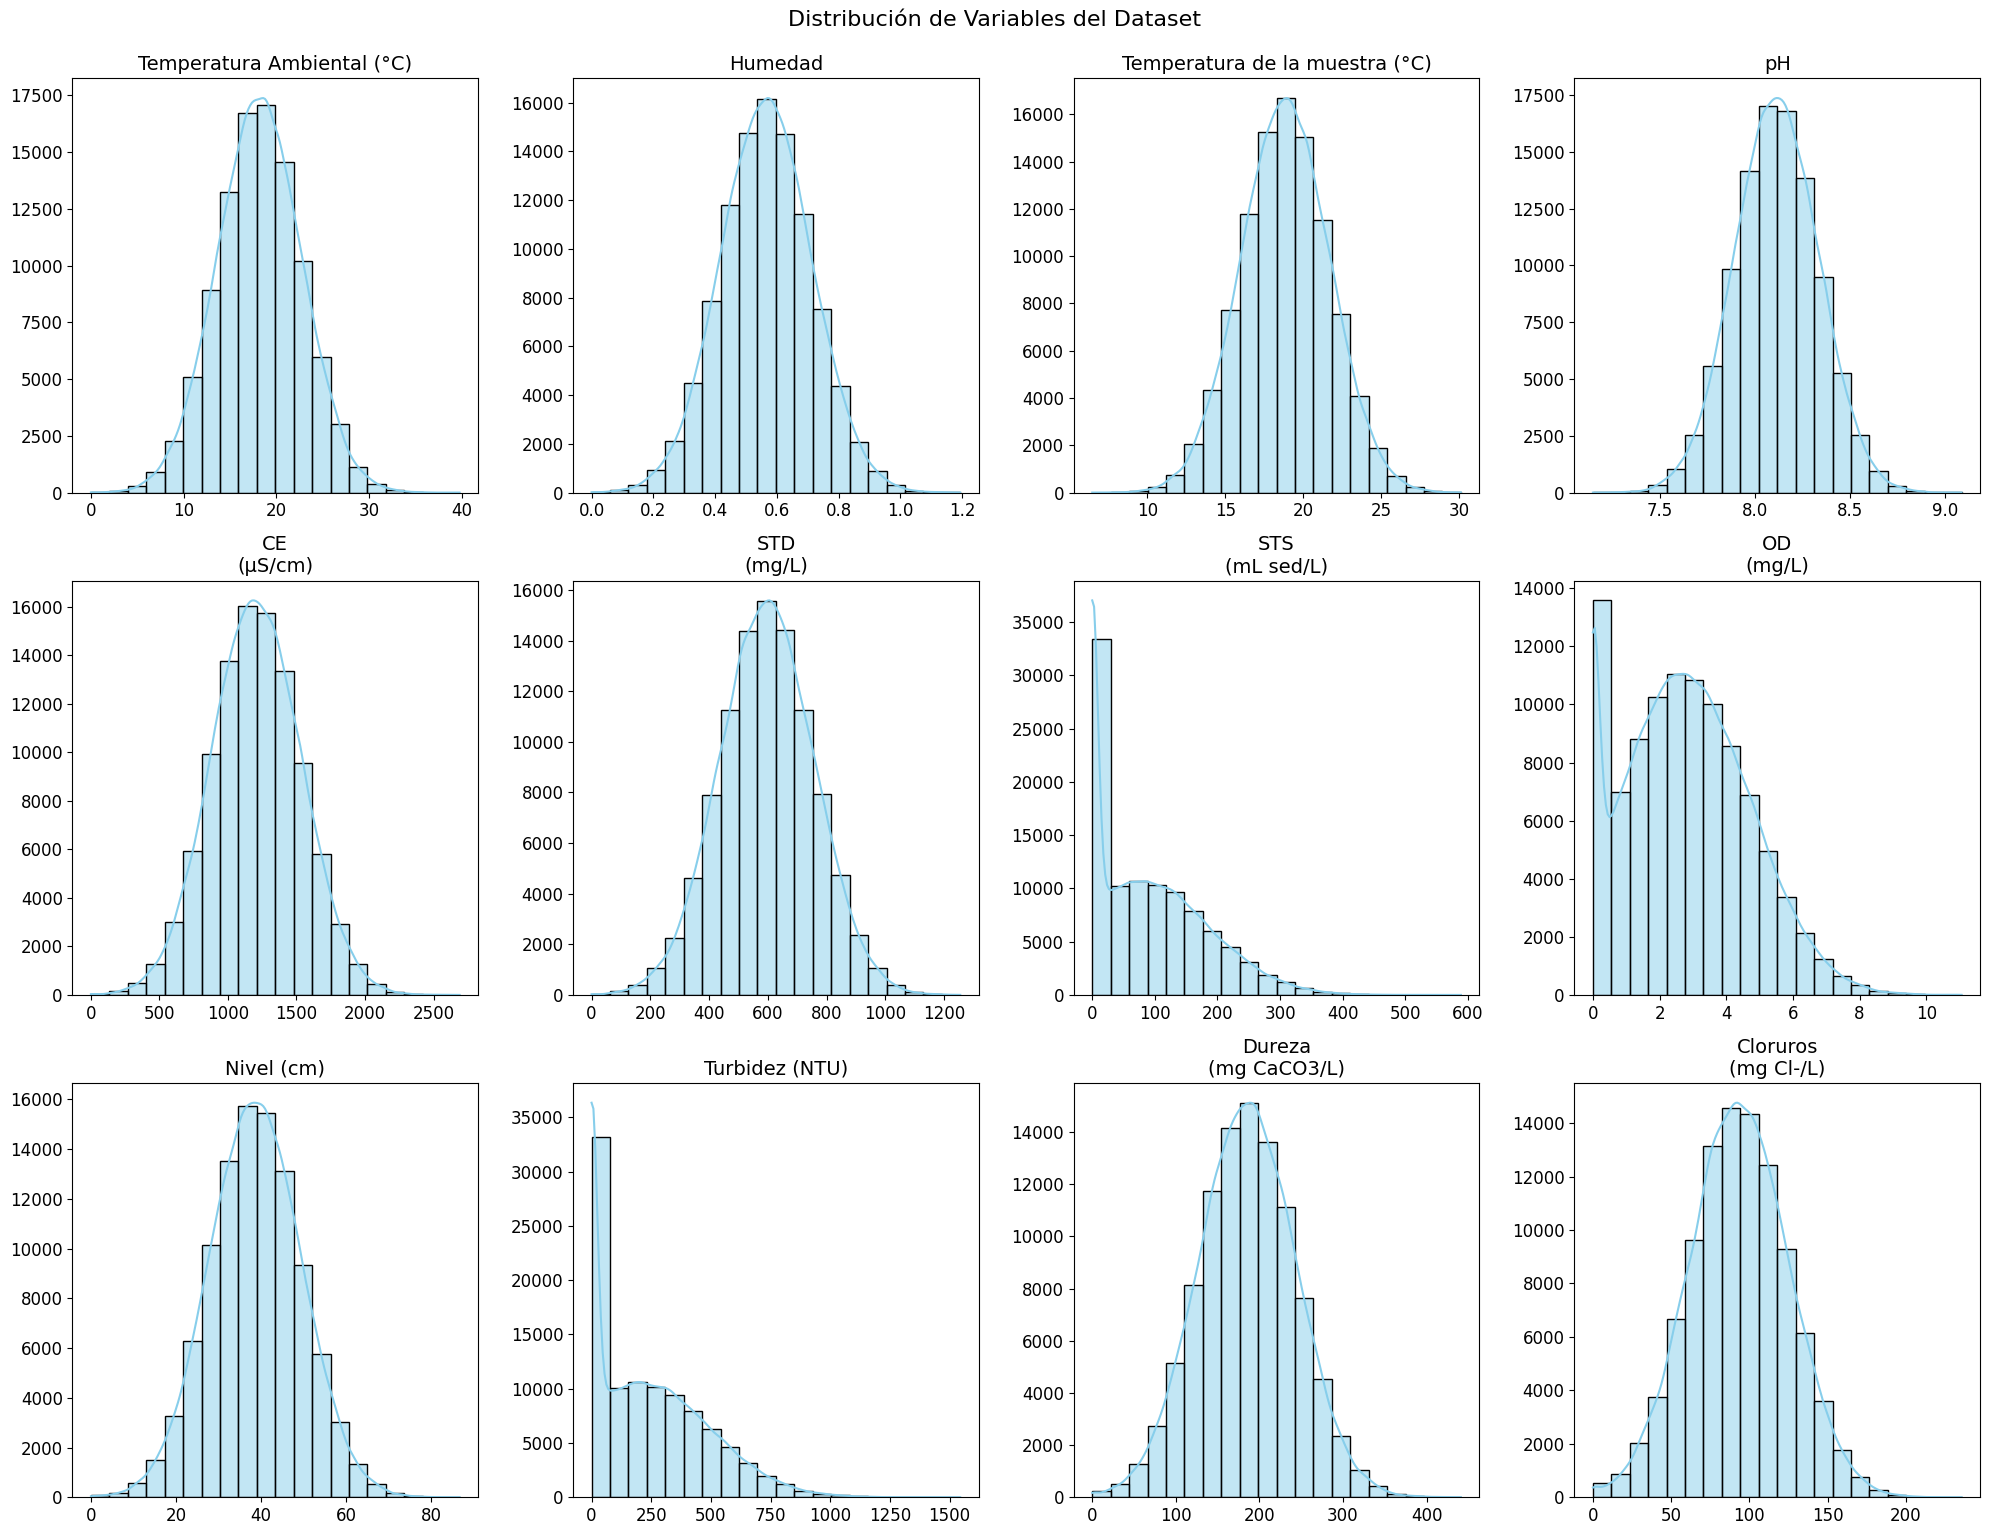

In [9]:
# Leé el CSV original para no modificar df_sin_nulos por las dudas
df_original = df_sin_nulos.copy()

# Creá un DataFrame vacío para guardar los resultados
df_simulado = pd.DataFrame()

# Número de simulaciones que querés hacer
num_simulaciones = 100000 #Si quiero tener en cuenta las relaciones entre las variables planteando escenarios:


for columna in df_original.columns:
    # Calculá la media y la desviación estándar de cada columna
    media = df_original[columna].mean()
    std = df_original[columna].std()

    # Generá datos aleatorios siguiendo una distribución normal
    datos_simulados = np.random.normal(media, std, num_simulaciones)

    # Añadí estos datos al DataFrame de resultados
    df_simulado[columna] = datos_simulados

# Truncate negative values to zero
df_simulado_truncado = df_simulado.apply(lambda x: np.where(x < 0, 0, x))
plot_results(df_simulado_truncado)
df_simulado_truncado.to_csv("./dataset_simulado_opcion_3.csv", index=False) #../



#### Simulación 4, distribuciones No Negativas

In [20]:

df_original = df_sin_nulos.copy()

# Create an empty DataFrame to store the log-normally distributed simulated data
df_simulado_lognormal = pd.DataFrame()

# Generate simulated data for each column using log-normal distribution
for col in df_original.columns:
    if df_original[col].dtype == 'float64':  # We only simulate for numerical columns
        # Remove zeros to avoid issues with log transformation
        non_zero_data = df_original[df_original[col] > 0][col]
        
        if len(non_zero_data) > 0:
            # Calculate the mean and standard deviation of the log-transformed data
            mu_log = np.log(non_zero_data).mean()
            sigma_log = np.log(non_zero_data).std()
            
            # Generate log-normal distributed random numbers
            lognormal_data = np.random.lognormal(mu_log, sigma_log, num_simulaciones)
            
            df_simulado_lognormal[col] = lognormal_data

# Calculate the mean and standard deviation for the log-normally distributed simulated data
mean_values_lognormal = df_simulado_lognormal.mean()
std_values_lognormal = df_simulado_lognormal.std()

plot_results(df_simulado_lognormal)
df_simulado_lognormal.to_csv("./dataset_simulado_opcion_4.csv", index=False) #../


ValueError: Number of rows must be a positive integer, not 0

<Figure size 2000x0 with 0 Axes>

_Nota al pié: La distribución log-normal suele funcionar bien para variables que son inherentemente no negativas y que tienen un sesgo hacia valores más grandes. Sin embargo, no todas las variables en tu conjunto de datos pueden ser buenos candidatos para una distribución log-normal desde un punto de vista físico o químico. Por ejemplo:_


- **Temperatura Ambiental (°C) y Temperatura de la Muestra (°C)**: Estas podrían ajustarse con una log-normal, pero en muchos casos una distribución normal podría ser más adecuada, especialmente si las temperaturas pueden fluctuar en ambos lados de una media.

- **Humedad y pH**: Estos son parámetros que ya tienen límites físicos (por ejemplo, el pH varía generalmente entre 0 y 14), y en muchos casos pueden estar bien descritos por una distribución normal en lugar de una log-normal.

- **STS (mL sed/L) y Turbidez (NTU)**: Estos parámetros describen la cantidad de partículas en el agua y podrían ajustarse bien a una log-normal, especialmente si hay una alta variabilidad y los valores son siempre positivos.

- **OD (mg/L)**: El oxígeno disuelto es un parámetro que también podría seguir una distribución log-normal, especialmente si hay una tendencia hacia valores bajos que no pueden ser negativos.

- **Nivel (cm), Dureza (mg CaCO3/L) y Cloruros (mg Cl-/L)**: Estos son parámetros que también podrían ajustarse bien con una log-normal, dado que son inherentemente no negativos.

_En resumen, el ajuste depende mucho del contexto específico y del rango de variabilidad de cada parámetro_

#### Simulación 5, re-simulación

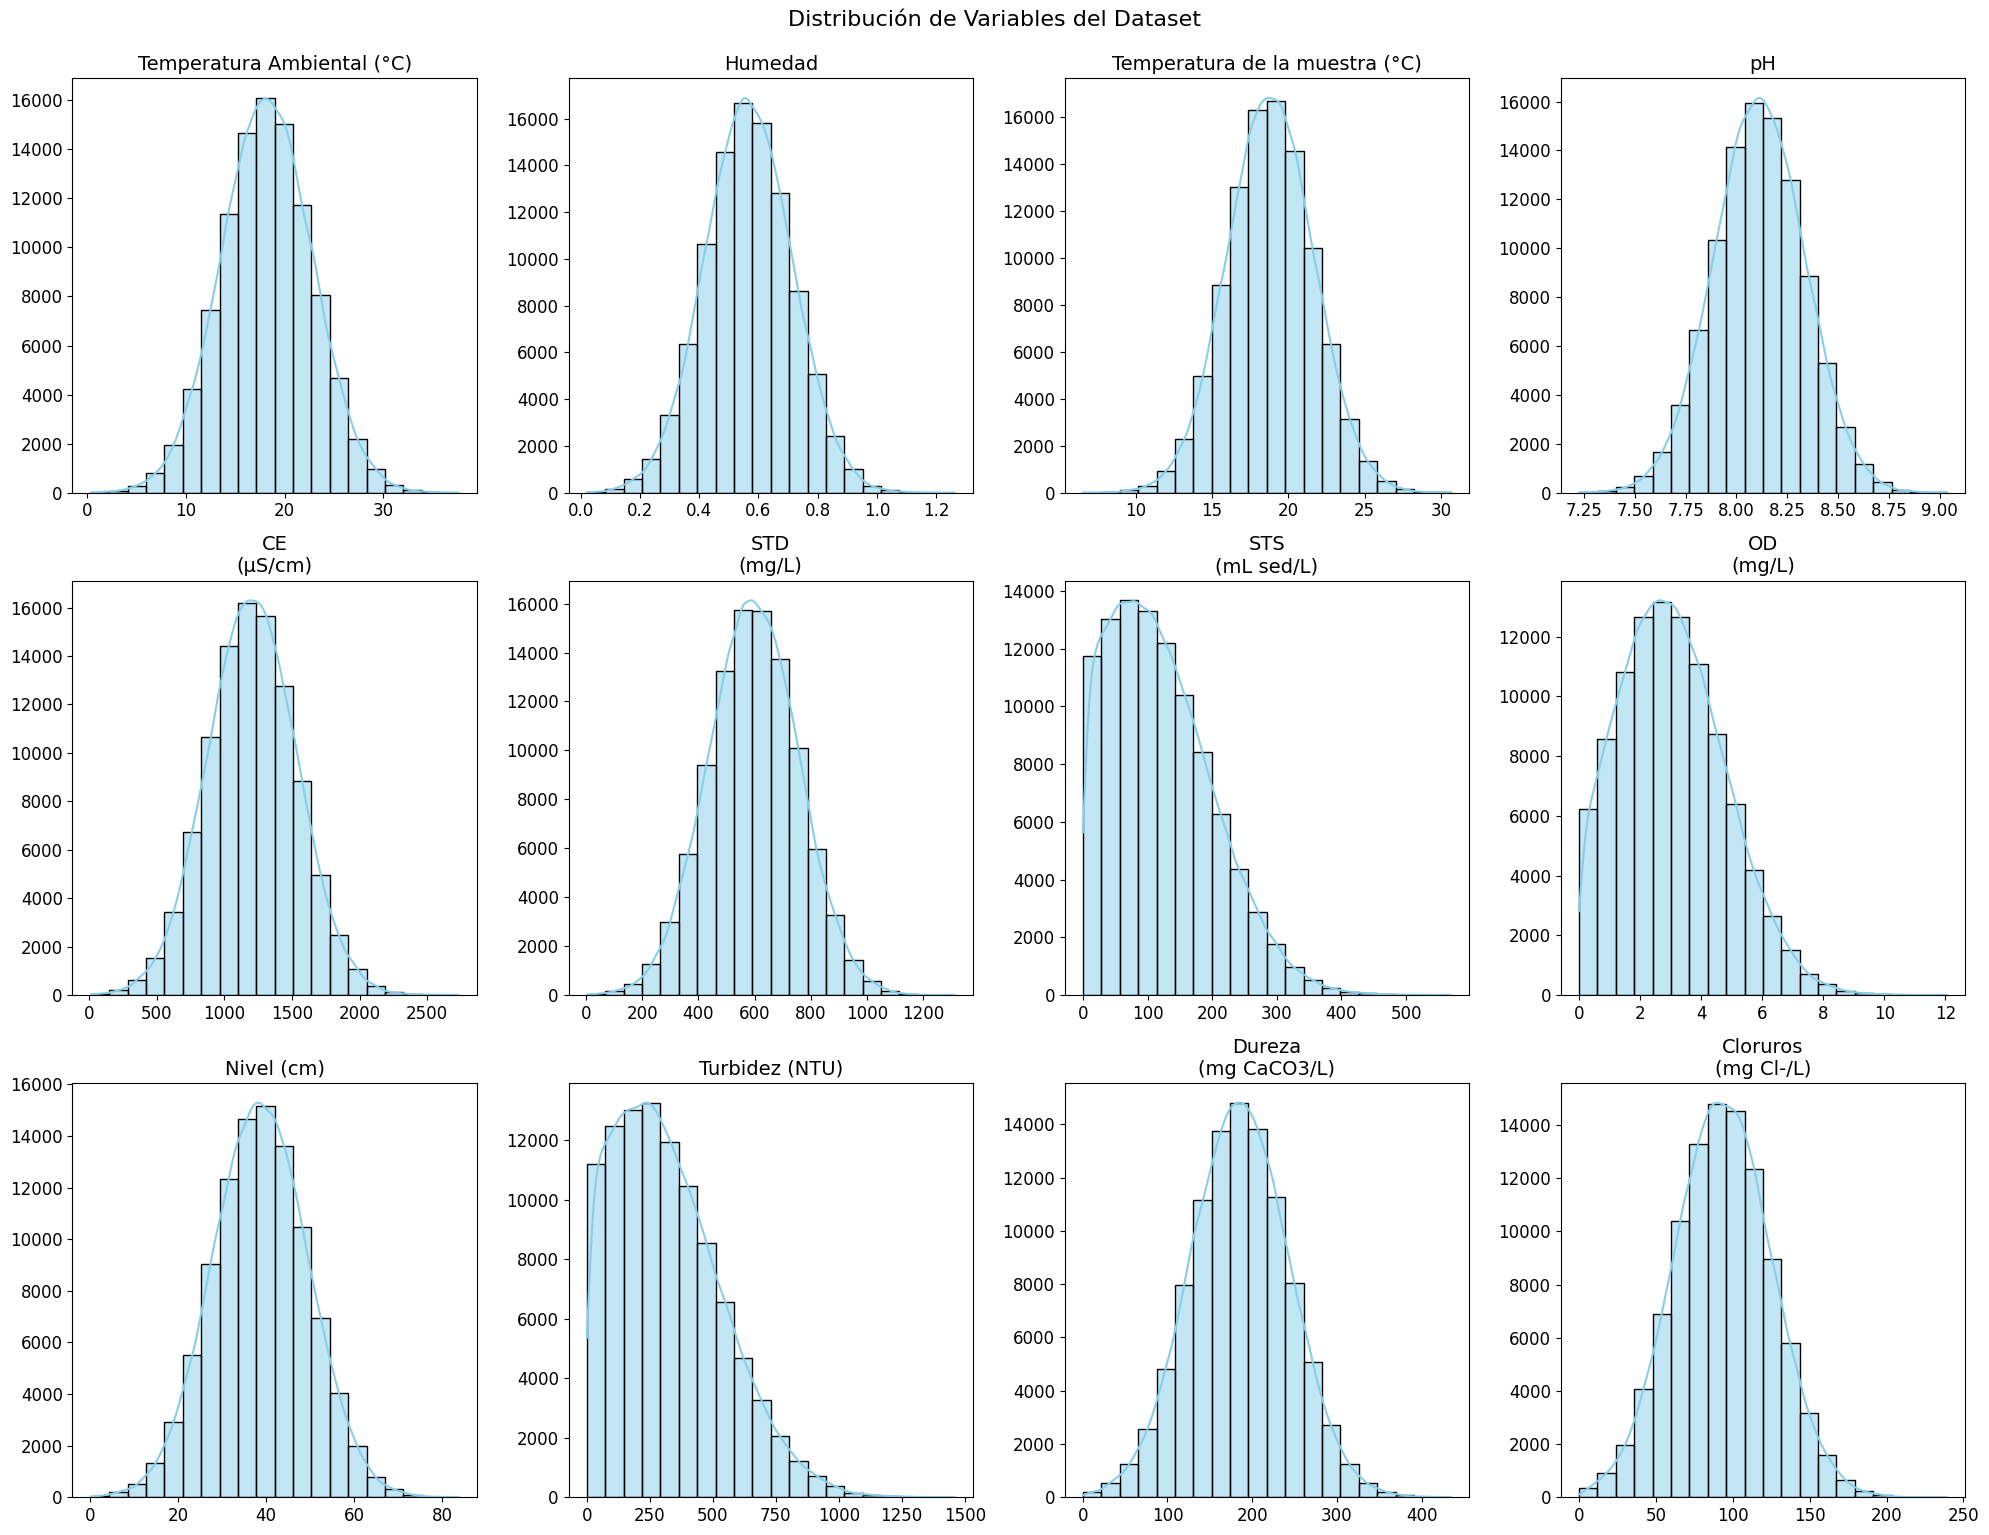

In [12]:
# Copia del DataFrame sin nulos para la simulación
df_original = df_sin_nulos.copy()

# Calculamos la media y la desviación estándar del DataFrame original
media_original = df_original.mean()
desviacion_original = df_original.std()

# Creamos un DataFrame vacío para guardar los datos re-simulados
df_simulado_resimulado = pd.DataFrame()

# Generamos datos re-simulados para cada columna
for columna in df_original.columns:
    media_columna = media_original[columna]  # Media
    desviacion_columna = desviacion_original[columna]  # Desviación estándar
    datos_simulados = np.random.normal(media_columna, desviacion_columna, num_simulaciones)
    
    # Re-simulamos cualquier valor negativo
    while np.any(datos_simulados < 0):
        datos_simulados[datos_simulados < 0] = np.random.normal(media_columna, desviacion_columna, np.sum(datos_simulados < 0))
    
    df_simulado_resimulado[columna] = datos_simulados

plot_results(df_simulado_resimulado)
df_simulado_resimulado.to_csv("./dataset_simulado_opcion_5.csv", index=False)

#### Simulación 6, Transformación de Datos

/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
/tmp/ipykernel_42805/393213518.py:30: RuntimeWarning: invalid value encountered in power
  datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda

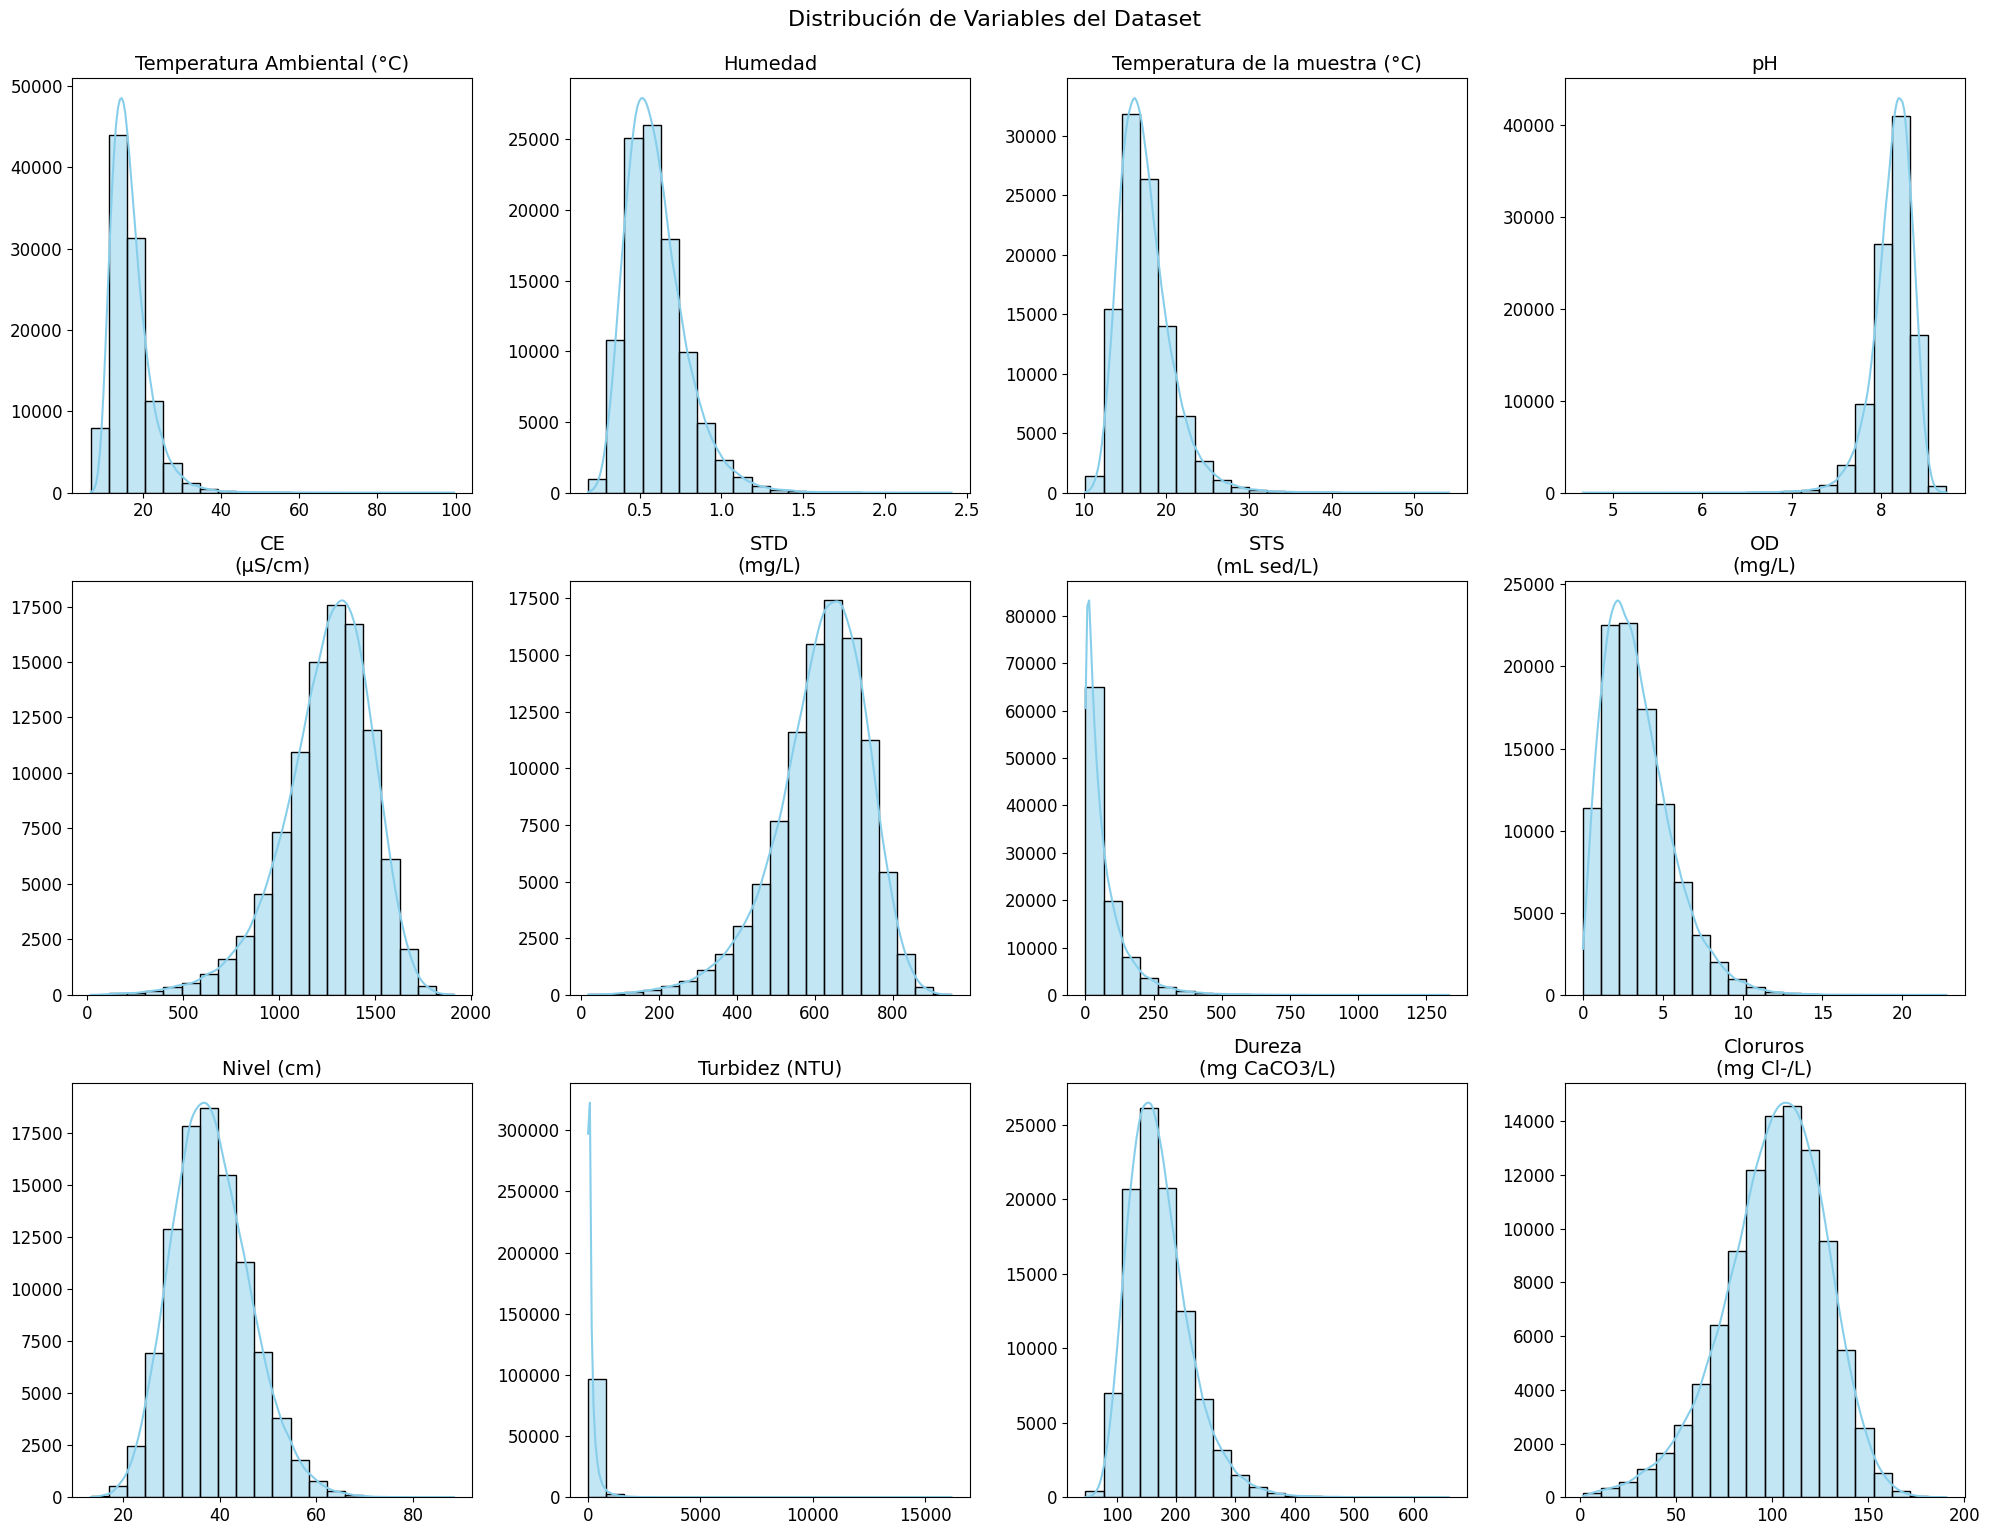

In [12]:
# Copia del DataFrame sin nulos para la simulación
df_original = df_sin_nulos.copy().astype('float64')



# Creamos un DataFrame vacío para guardar los datos transformados con Box-Cox
df_simulado_boxcox = pd.DataFrame()

# Generamos datos simulados para cada columna usando la transformación Box-Cox
for columna in df_original.columns:

    # Eliminamos los ceros para evitar problemas con la transformación Box-Cox
    datos_sin_cero = df_original[df_original[columna] > 0][columna]
    
    if len(datos_sin_cero) > 0:
        # Aplicamos la transformación Box-Cox
        datos_transformados, valor_lambda = boxcox(datos_sin_cero)
        
        # Calculamos la media y la desviación estándar de los datos transformados
        media_transformada = np.mean(datos_transformados)
        desviacion_transformada = np.std(datos_transformados)
        
        # Generamos números aleatorios con distribución normal
        datos_normales = np.random.normal(media_transformada, desviacion_transformada, num_simulaciones)
        
        # Aplicamos la transformación inversa de Box-Cox
        if valor_lambda == 0:
            datos_simulados = np.exp(datos_normales)
        else:
            datos_simulados = (valor_lambda * datos_normales + 1) ** (1 / valor_lambda)
        
        df_simulado_boxcox[columna] = datos_simulados

plot_results(df_simulado_boxcox)
df_simulado_boxcox.to_csv("./dataset_simulado_opcion_6.csv", index=False)

## Explicación de la transformación Box-Cox

La transformación Box-Cox es una familia de transformaciones potenciales que se utilizan para estabilizar la varianza y hacer que un dataset se ajuste mejor a una distribución normal. La fórmula general de la transformación Box-Cox para un conjunto de datos \( x \) y un parámetro \( \lambda \) es la siguiente:

\[
y(x) =
\begin{cases} 
\frac{{x^\lambda - 1}}{\lambda} & \text{si } \lambda \neq 0 \\
\ln(x) & \text{si } \lambda = 0 
\end{cases}
\]

### Simulación de Datos

1. **Datos originales sin ceros**: Primero, se eliminan los ceros del conjunto de datos original para cada columna, ya que la transformación Box-Cox no se define para \( x \leq 0 \).

2. **Aplicar Box-Cox**: Luego, se aplica la transformación Box-Cox a estos datos para obtener un conjunto transformado. Esta transformación se hace para que los datos transformados se ajusten mejor a una distribución normal.

3. **Calcular estadísticas**: Se calculan la media y la desviación estándar de los datos transformados.

4. **Generar datos aleatorios**: Se generan datos aleatorios con una distribución normal usando la media y la desviación estándar calculadas. Estos datos son una simulación de los datos transformados.

### Transformación Inversa de Box-Cox

Una vez que se tienen los datos simulados, se aplica la transformación inversa de Box-Cox para llevarlos de vuelta al espacio original. La fórmula de la transformación inversa es:

\[
x(y) =
\begin{cases} 
(e^y) & \text{si } \lambda = 0 \\
((\lambda y + 1)^{1/\lambda}) & \text{si } \lambda \neq 0 
\end{cases}
\]

Esta transformación inversa se aplica a los datos simulados para obtener un nuevo conjunto de datos que tiene las mismas propiedades estadísticas que el conjunto de datos original pero con la varianza estabilizada y una forma más cercana a la normalidad.
